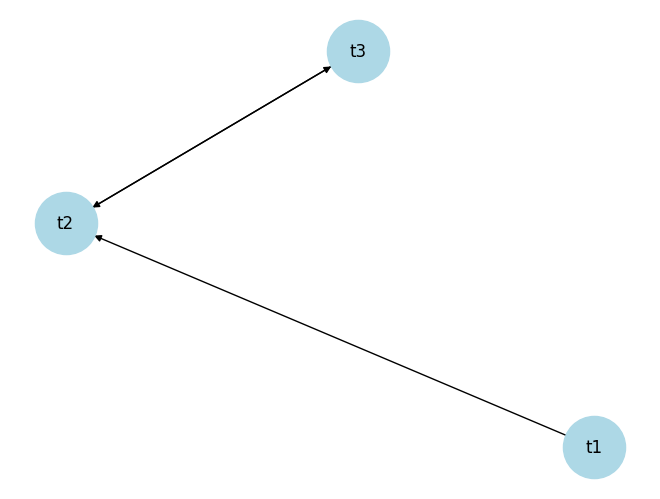

Feasibility Matrix:


dev_id,d1,d2
task_id,,
t1,1,1
t2,0,0
t3,1,1


Development Time Matrix:


dev_id,d1,d2
task_id,,
t1,24.0,30
t2,40.0,50
t3,16.0,20


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

class Config:
    T_BASE = 0
    P = 0
    Q = 0
    DELTA_PARALLEL = 0

def initialize(t_base, p, q, delta_parallel):
    Config.T_BASE = t_base
    Config.P = p
    Config.Q = q
    Config.DELTA_PARALLEL = delta_parallel

initialize(10, 0.8, 1.2, 2.0)

# 1. Tasks: Key attributes for scheduling
tasks = pd.DataFrame({
    'task_id': ['t1', 't2', 't3'],
    'sp': [3, 5, 2], # Story points
    'type': ['backend', 'database', 'backend'],
    'module': ['auth', 'data', 'auth']
})
tasks = tasks.set_index('task_id')

# 2. Developers: Skills and team ownership
developers = pd.DataFrame({
    'dev_id': ['d1', 'd2'],
    'profile': [['backend', 'database'], ['backend']], # Skills
    'team': ['team_A', 'team_A'],
    'exp': ['A', 'I'],
    'availability': [[(0, 100)], [(0, 100)]]
})
developers = developers.set_index('dev_id')
module_to_team = {
    'auth': 'team_A',
    'data': 'team_B'
}
tasks['team_required'] = tasks['module'].map(module_to_team)
multipliers = {
    'I': 1, # Intermediate
    'A': Config.P, # Advanced
    'B': Config.Q # Beginner
}

# 3. Dependencies between tasks
dependencies = [
        ('t1', 't2', {'relation': 'acyc'}), 
        ('t2', 't3', {'relation': 'cyc'})
    ]

# Utilities
def create_lookup(df, index_name):
    """
    Creates a function that retrieves a row from 'df' based on a key matching the 'index_name'.
    """
    # Ensure the dataframe is indexed correctly
    if df.index.name != index_name:
        df = df.set_index(index_name)
        
    def lookup(object_id):
        return df.loc[object_id]
    
    return lookup

get_task = create_lookup(tasks, 'task_id')
get_dev = create_lookup(developers, 'dev_id')

def build_dependency_graph(tasks, dependencies):
    G = nx.DiGraph()
    
    # Add nodes
    task_data = tasks.to_dict('index')
    for task_id, data in task_data.items():
        G.add_node(task_id, **data)

    # Automatically handle cyclic back-edges
    for u, v, attr in dependencies:
        G.add_edge(u, v, **attr)
        if attr.get('relation') == 'cyc':
            # Create the reciprocal edge automatically
            G.add_edge(v, u, **attr) 

    # Calculate dep_count
    for node in G.nodes():
        G.nodes[node]['dep_count'] = len(nx.descendants(G, node))
        
    return G

def display_dependency_graph(G):
    nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000)
    plt.show()

def check_feasibility(task_id, dev_id):
    """
    Checks whether the developer (dev_id) is eligible for the giving task (task_id)
    """
    task = get_task(task_id)
    dev = get_dev(dev_id)
    
    # Rule 1: Skill Matching
    skill_match = task['type'] in dev['profile']

    # Rule 2: Team-Module Ownership
    team_match = dev['team'] == task['team_required']
    
    return skill_match and team_match

def calculate_coordination_risk(u, v, su, fu, sv, fv, G):
    """
    Calculates the Coordination Risk (CR) based on the scheduling relationship between task_i and task_k.
    """
    overlap = min(fu, fv) - max(su, sv)
    
    # Sequential condition
    if overlap < Config.DELTA_PARALLEL:
        return 0
    
    # Parallel condition for acyclic (cyclic risk is handled by the cycle loop beneath)
    return 1 + G.nodes[v].get('dep_count', 0)

def a_dev_time(task_id, dev_id):
    # dev_time(t_i, d_j) = sp(t_i) * T_{base} * beta(exp(d_j))
    task = get_task(task_id)
    dev = get_dev(dev_id)
    exp = dev['exp']

    return task['sp'] * Config.T_BASE * multipliers.get(exp)

def build_feasibility_matrix(tasks, developers):
    matrix_data = []

    for task_id in tasks.index:
        row = []
        for dev_id in developers.index:
            if check_feasibility(task_id, dev_id):
                row.append(1)
            else:
                row.append(0)
        matrix_data.append(row)

    return pd.DataFrame(
        matrix_data, 
        index=tasks.index, 
        columns=developers.index
    )

def display_feasibility_matrix(F):
    print("Feasibility Matrix:")
    display(F)

def individual_workload(dev_id, tasks):
    return sum(a_dev_time(task_id, dev_id) for task_id in tasks.index)

def build_dev_times_matrix(tasks, developers):
    """
    Builds a matrix where rows are tasks and columns are developers,
    containing the calculated development time for each pair.
    """
    matrix_data = []

    for task_id in tasks.index:
        row = []
        for dev_id in developers.index:
            duration = a_dev_time(task_id, dev_id)
            row.append(duration)
        matrix_data.append(row)

    return pd.DataFrame(
        matrix_data, 
        index=tasks.index, 
        columns=developers.index
    )

def display_dev_times_matrix(D):
    print("Development Time Matrix:")
    display(D)

def calculate_average_workload(x_ij, dev_times):
    """
    x_ij: DataFrame where rows are tasks, columns are developers (1 if assigned, 0 otherwise). \\
    dev_times: Matrix of pre-calculated completion times for each task/dev pair.
    """
    # Multiply assignment matrix by duration matrix
    individual_workloads = (x_ij * dev_times).sum(axis=0)
    
    # Calculate average W
    return individual_workloads.mean()

def calculate_makespan(schedule):
    # Makespan is simply the maximum finish time
    return schedule['finish'].max()

def calculate_workload_imbalance(schedule):
    # Calculates the standard deviation of total duration per developer
    schedule['duration'] = schedule['finish'] - schedule['start']
    workloads = schedule.groupby('assigned_dev')['duration'].sum()
    return np.std(workloads)

def calculate_total_coordination_risk(G, schedule):
    total_risk = 0
    
    # 1. Sum Acyclic Risks (P_acyc)
    # Filter edges that are NOT part of any cycle
    for u, v, data in G.edges(data=True):
        if data.get('relation') == 'acyc':
            su, fu = schedule.loc[u, 'start'], schedule.loc[u, 'finish']
            sv, fv = schedule.loc[v, 'start'], schedule.loc[v, 'finish']
            total_risk += calculate_coordination_risk(u, v, su, fu, sv, fv, G)

    # 2. Sum Cyclic Risks (P_cyc)
    # Aggregated per cycle as defined in Equation (9) and (10)
    for cycle in nx.simple_cycles(G):
        cycle_risk = 0
        for i in range(len(cycle)):
            u = cycle[i]
            v = cycle[(i + 1) % len(cycle)]
            # Cyclic dependencies must be in parallel
            cycle_risk += (1 + G.nodes[v].get('dep_count', 0))
        total_risk += cycle_risk
        
    return total_risk

def check_constraints(schedule, developers, dependencies):
    
    for task_id, row in schedule.iterrows():
        dev_id = row['assigned_dev']
        s_i, f_i = row['start'], row['finish']
        
        # 1. Skill & Team Constraints
        if check_feasibility(task_id, dev_id) == False: return False

        # 2. Availability Constraint: Task [s_i, f_i] must fit in one of dev's slots
        is_available = False
        for slot_start, slot_end in developers.loc[dev_id, 'availability']:
            if s_i >= slot_start and f_i <= slot_end:
                is_available = True
                break
        if not is_available:
            print(f"Constraint Violated: {task_id} interval [{s_i}, {f_i}] outside {dev_id} availability.")
            return False

    # 3. Flow Constraints (Acyclic & Cyclic)
    for u, v, attr in dependencies:
        su, fu = schedule.loc[u, 'start'], schedule.loc[u, 'finish']
        sv, fv = schedule.loc[v, 'start'], schedule.loc[v, 'finish']
        
        if attr['relation'] == 'acyc':
            if sv < (fu - Config.DELTA_PARALLEL): return False
        elif attr['relation'] == 'cyc':
            overlap = min(fu, fv) - max(su, sv)
            if overlap < Config.DELTA_PARALLEL : return False

    # 4. Resource Constraint (No overlapping tasks for the same dev)
    for dev_id in schedule['assigned_dev'].unique():
        dev_tasks = schedule[schedule['assigned_dev'] == dev_id].sort_values('start')
        for i in range(len(dev_tasks) - 1):
            if dev_tasks.iloc[i+1]['start'] < dev_tasks.iloc[i]['finish']:
                return False 

    return True

G = build_dependency_graph(tasks, dependencies)
display_dependency_graph(G)

F = build_feasibility_matrix(tasks, developers)
display_feasibility_matrix(F)

D = build_dev_times_matrix(tasks, developers)
display_dev_times_matrix(D)